# Exploring structures

In this tutorial we will deposit a particle dataset from a cosmological N-body simulation with different structures and investigate the advantages of certain structures wrt. dynamic range and power spectrum analysis.

First, let's load all necessary packages and modules.

In [14]:
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import smudgy as sm
from powerbox import get_power

In [15]:
try:
    plt.style.use('custom')
except:
    pass
%matplotlib inline
%config InlineBackend.figure_format='retina'

As discussed in the Kernels and Structures wiki page, `smudgy` supports `separable`, `iso-` and `anisotropic` structures. Currently, only `tophat`, `tsc` and `gaussian` kernels can be used for `separable` structures, while all kernels can be used for the other two.

Let's define the structures and a dict with kernel names to analyze.

In [16]:
structures = ['separable', 'isotropic', 'anisotropic']
kernel_name = 'gaussian'

colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(structures)]

```{image} kernel_shapes.png
:width: 100%
:align: center

## Effect of kernel structure on Power Spectrum

Interpolation and deposition results almost always depend on the chosen structure. We demonstrate this in the following workflow, where we deposit particles from a cosmological N-body simulation using different structures.

First, we compute a reference grid using Nearest Grid Point assignment (NGP), which is often used in such applications. Then, with NGP as the baseline we compare the results by using higher order structures and finally show the relative difference on the power spectrum.

We use the TNG50-4-Dark simulation from the publically available [TNG](https://www.tng-project.org/data/) runs as well as the `illustris_python` package to load `positions`, `masses` and the `boxsize` information.

In [17]:
import illustris_python as il

basePath = '/Users/mauro/work/projects/smudgy/data/tng50_4_dark/'
snapNum = 99
boxsize = 35
dm = il.snapshot.loadSubset(basePath, snapNum, "dm")

positions = dm['Coordinates'] / 1000 # in Mpc
masses = np.ones(len(positions))# * 0.0186754872146347 * 1e10 # in Msun/h
positions = np.clip(positions, 0.1, boxsize-0.1)

Then we initialize a `PointCloud` object, set some parameters to use during later computations and compute the smoothing lengths.

In [18]:
gridnums = 400
num_neighbors = 8

cloud = sm.PointCloud(
    positions=positions,
    weights=masses,
    boxsize=boxsize
    )

kwargs = dict(
    averaged=False,
    gridnums=gridnums,
    eta_crit=1,
    omp_threads=10,
)

[smudgy] Initialized 3d PointCloud with 19683000 particles in periodic box of size=[35 35 35]


Next we compute the reference grid using NGP and perform the depositions by looping over the different kernels.

In [19]:
f_ref = cloud.deposit_to_grid(
    **kwargs,
    fields=cloud.weights,
    kernel_name='ngp',
)[..., 0]

pk_ref, k_ref = get_power(f_ref, boxlength=boxsize)

power_spectra = []
for structure in structures:

    cloud.global_setup(num_neighbors=num_neighbors, structure=structure, kernel_name=kernel_name)
    cloud.compute_smoothing()

    f = cloud.deposit_to_grid(
        **kwargs,
        fields=cloud.weights,
    )[..., 0]
    p, k = get_power(f, boxlength=boxsize)
    power_spectra.append(p)

[smudgy] Using c++ backend for ngp deposition (ngp_3d)


/opt/anaconda3/envs/my_env/lib/python3.12/site-packages/powerbox/tools.py:261: FutureWarning: In the future, bins will be generated by default up to the smallest length over any dimension, instead of the largest magnitude for the box.Set bins_upto_boxlen to silence this warning.
  bins = _getbins(bins, coord_mags, log_bins, bins_upto_boxlen=bins_upto_boxlen)


[smudgy] Set structure globally to 'separable'
[smudgy] Set kernel globally to 'gaussian'
[smudgy] Set number of neighbors globally to 8
[smudgy] Building kd-tree from particle positions
[smudgy] Computing smoothing lengths from 8 neighbors
[smudgy] Using c++ backend for separable deposition (separable_3d)
[smudgy] Set structure globally to 'isotropic'
[smudgy] Set kernel globally to 'gaussian'
[smudgy] Set number of neighbors globally to 8
[smudgy] Computing smoothing lengths from 8 neighbors
[smudgy] Using c++ backend for isotropic deposition (isotropic_3d)
[smudgy] Set structure globally to 'anisotropic'
[smudgy] Set kernel globally to 'gaussian'
[smudgy] Set number of neighbors globally to 8
[smudgy] Computing smoothing tensors from 8 neighbors
[smudgy] Using c++ backend for anisotropic deposition (anisotropic_3d)


```{image} structure_projection_comparison.png
:width: 100%
:align: center

Finally we compare the power spectra wrt. the baseline (NGP). For the chosen deposition parameters, we see that different kernels can have a relatively large impact (order percentage) especially on scales $x \leq 1 \, \mathrm{cMpc}/h$

/var/folders/g9/6lkt0k991jsbvwhk4pft359m0000gn/T/ipykernel_8839/2830439443.py:12: RuntimeWarning: divide by zero encountered in divide
  return 2 * np.pi / x


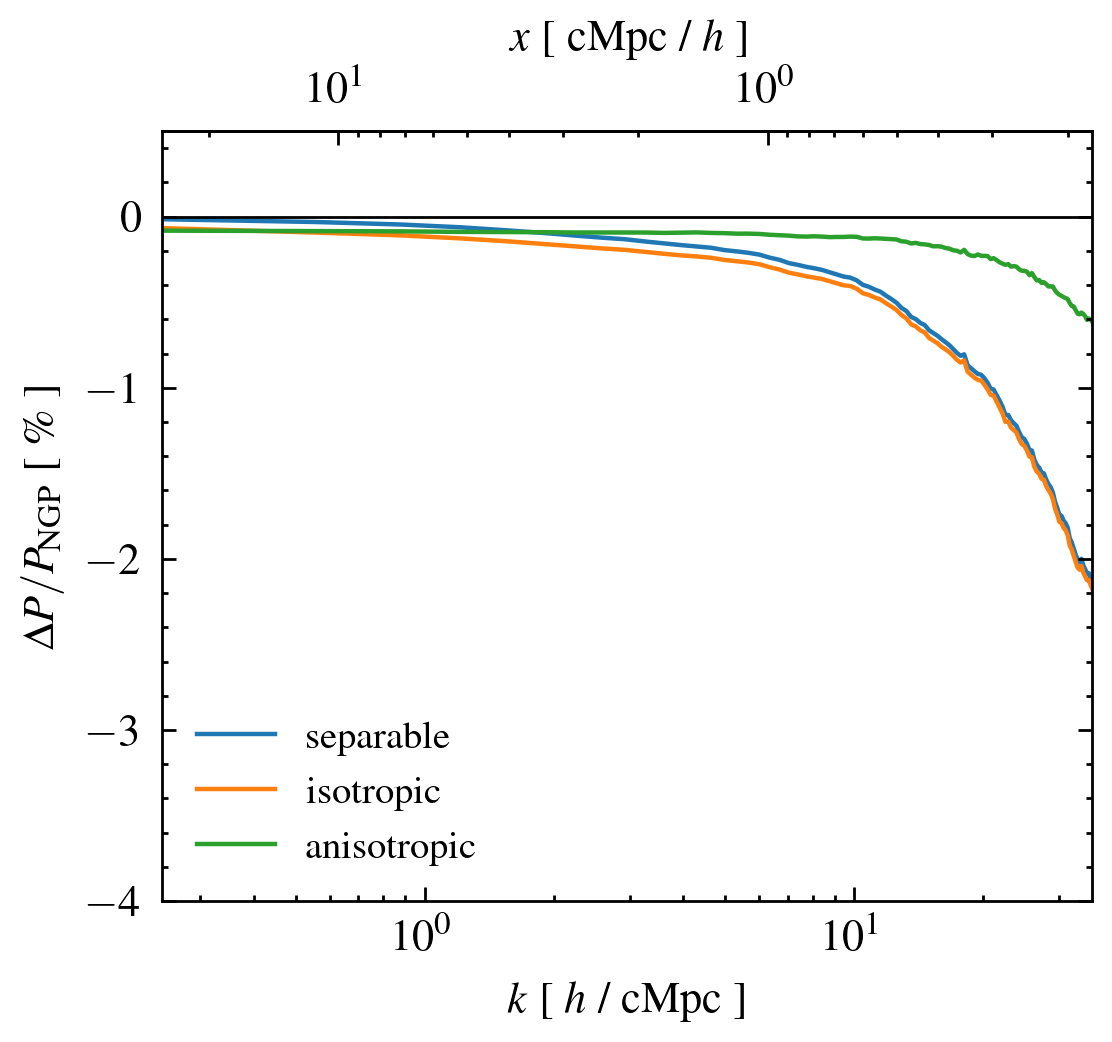

In [22]:
def relative_difference(a, b):
    # Avoid division by zero
    mask = (b != 0)
    res = np.zeros_like(a)
    res[mask] = (a[mask] - b[mask]) / b[mask] * 100
    return res

def k2x(k):
    return 2 * np.pi / k

def x2k(x):
    return 2 * np.pi / x

# set k_nyq to upper xlim
k_nyq = np.pi * gridnums / boxsize

fig, ax = plt.subplots(figsize=(3, 2.5))
for i, name in enumerate(structures):

    # relatvie difference to reference
    rel_diff = relative_difference(power_spectra[i], pk_ref)

    ax.semilogx(k, rel_diff, label=name, lw=0.8, color=colors[i])

ax_top = ax.secondary_xaxis('top', functions=(k2x, x2k))
ax_top.set_xlabel(r"$x$ [ cMpc / $h$ ]")
ax_top.tick_params(which='both', top=True, labeltop=True)
ax.tick_params(which='both', top=False, labeltop=False)

ax.axhline(0, color='k', linestyle='-', lw=0.5)
ax.legend(fontsize=7, ncols=1, loc='lower left')
ax.set(xlim=(k_ref.min(), k_nyq),
       ylim=(-4, 0.5),
       xlabel=r"$k$ [ $h$ / cMpc ]",
       ylabel=r"$\Delta P / P_{\rm NGP}$ [ \% ]",
       )

fig.savefig("structure_power_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
#plt.close()

```{image} kernel_power_comparison.png
:width: 70%
:align: center